# Local Search: Implementasi Hill Climbing pada Travelling Salesman Problem (TSP)

**Cara memakai notebook ini:** jalankan cell dari atas ke bawah (`Shift + Enter`). Setelah tiap output, cocokkan dengan penjelasan di Markdown sebelum lanjut.

## 1. Tujuan
Setelah praktikum ini, kita dapat:
1. memahami konsep **Local Search**;
2. memahami **Hill Climbing**;
3. memahami **state**, **neighbor**, dan **cost function**;
4. memodelkan **TSP**;
5. mengimplementasikan Hill Climbing **dari nol**;
6. melihat proses pencarian **secara bertahap**;
7. memahami **keterbatasan** Hill Climbing.

**Istilah penting**

| Istilah | Arti sederhana | Pada TSP di notebook ini |
|---|---|---|
| State | Satu solusi yang sedang dipegang | Satu urutan kota, mis. `[A, B, C, D, E]` |
| Neighbor | State tetangga (beda sedikit) | Route hasil menukar 2 kota |
| Cost | Nilai keburukan state | Total jarak perjalanan |
| Local optimum | Lebih baik dari semua tetangganya, tapi belum tentu terbaik secara keseluruhan | Route tempat Hill Climbing berhenti |

## 2. Local Search dan Jenis-jenisnya

**Local Search** adalah keluarga algoritma pencarian yang bekerja pada **satu (atau beberapa) state saat ini** lalu memperbaikinya lewat perpindahan ke **neighbor**. Berbeda dengan BFS/DFS, ia **tidak menyimpan jalur** dan tidak menelusuri seluruh search space, sehingga hemat memori. Cocok untuk masalah optimasi seperti TSP, penjadwalan, dan penempatan.

**Jenis-jenis Local Search**

| Algoritma | Ide singkat | Kelebihan / Catatan |
|---|---|---|
| **Hill Climbing** | Selalu pindah ke neighbor yang lebih baik, berhenti jika tidak ada | Sederhana dan cepat; bisa terjebak di local optimum |
| **Simulated Annealing** | Seperti Hill Climbing, tetapi kadang boleh pindah ke neighbor yang *lebih buruk* (peluang mengecil seiring waktu) | Dapat lolos dari local optimum |
| **Genetic Algorithm** | Populasi state yang "kawin silang" dan bermutasi | Eksplorasi luas; lebih kompleks |

**Variasi Hill Climbing**

| Varian | Cara memilih neighbor |
|---|---|
| **Steepest-ascent** (yang kita pakai) | Cek **semua** neighbor, ambil yang **terbaik** |
| **First-choice / Simple** | Ambil neighbor **pertama** yang lebih baik dari current |
| **Stochastic** | Pilih **acak** di antara neighbor yang lebih baik |
| **Random-restart** | Jalankan Hill Climbing berkali-kali dari initial state acak, ambil hasil terbaik |


### Hill Climbing: Konsep Inti

**Analogi:** kamu berdiri di sebuah bukit berkabut dan ingin naik setinggi mungkin. Kamu tidak bisa melihat seluruh peta, hanya **langkah di sekitarmu**. Setiap kali, kamu melangkah ke arah yang paling menanjak; kalau semua arah menurun, kamu berhenti. Itulah Hill Climbing. (Pada TSP kita ingin cost **serendah** mungkin, jadi "mendaki" berarti *menurunkan cost*.)

**Local Search**
- fokus pada *current state* (hanya satu state yang dipegang, tidak menyimpan semua kemungkinan)
- melihat *neighbor* dari state tersebut
- berpindah ke state yang lebih baik

**Hill Climbing**
1. mulai dari initial state
2. generate neighbors
3. evaluasi neighbors
4. pilih neighbor terbaik
5. pindah jika lebih baik
6. berhenti jika tidak ada improvement

```text
current = initial_state
loop:
    neighbors = generate_neighbors(current)
    best = neighbor dengan cost terkecil
    if cost(best) < cost(current):
        current = best        # pindah
    else:
        return current        # berhenti
```

## 3. Contoh Singkat
Misalkan current cost = **20**, dan tiga neighbor-nya: **A = 17**, **B = 14**, **C = 18**.

Karena ini masalah *minimization* (makin kecil makin baik), neighbor terbaik adalah **B (14)**. Karena 14 < 20, kita **pindah: 20 → 14**.

Dari state baru itu, proses diulang: buat neighbor baru, pilih yang terbaik, pindah jika lebih baik. Berhenti saat **tidak ada neighbor yang lebih baik** dari current state. Sekarang kita lihat langsung pada kode.

In [1]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

## 4. Case Study: TSP 5 Kota
**Travelling Salesman Problem (TSP):** seorang salesman harus mengunjungi sejumlah kota. Ia harus:
- mengunjungi setiap kota **satu kali**
- **kembali** ke kota awal
- meminimalkan **total jarak** perjalanan


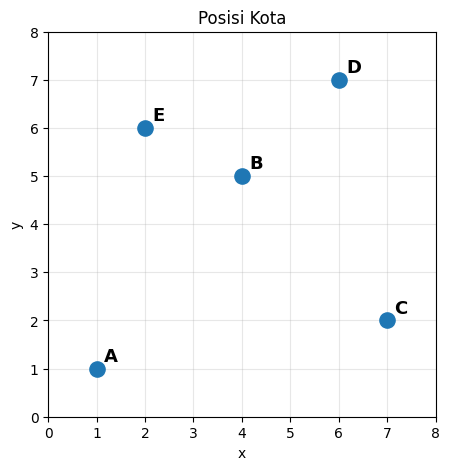

In [2]:
cities = {
    "A": (1, 1),
    "B": (4, 5),
    "C": (7, 2),
    "D": (6, 7),
    "E": (2, 6),
}

plt.figure(figsize=(5, 5))
for name, (x, y) in cities.items():
    plt.scatter(x, y, s=120, color="tab:blue", zorder=3)
    plt.text(x + 0.15, y + 0.15, name, fontsize=13, fontweight="bold")
plt.title("Posisi Kota")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.xlim(0, 8); plt.ylim(0, 8)
plt.show()

## 5. Representasi State
Di Local Search, **state** adalah "kondisi/solusi yang sedang kita pegang". Pada TSP, state kita adalah **urutan kunjungan kota** yang disimpan sebagai list Python.

`["A", "B", "C", "D", "E"]` artinya salesman berjalan **A → B → C → D → E**, lalu **kembali ke A**.

In [3]:
def route_to_string(route):
    # Tampilkan route beserta kembalinya ke kota awal
    return " → ".join(route + [route[0]])

contoh_route = [
    ["A", "B", "C", "D", "E"],
    ["A", "C", "B", "D", "E"],
    ["A", "D", "C", "B", "E"],
]
for r in contoh_route:
    print(route_to_string(r))

A → B → C → D → E → A
A → C → B → D → E → A
A → D → C → B → E → A


## 6. Distance Function
Sebelum menilai sebuah route, kita perlu bisa mengukur jarak **dua kota**. Kita pakai jarak Euclidean (jarak garis lurus):

$$d = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$$

misalnya A(1,1) ke B(4,5): $\sqrt{3^2+4^2}=5$.

In [4]:
def calculate_distance(city1, city2):
    x1, y1 = cities[city1]
    x2, y2 = cities[city2]
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

for c1, c2 in [("A", "B"), ("B", "C"), ("C", "D"), ("D", "E"), ("E", "A"), ("A", "C")]:
    print(f"Jarak {c1}-{c2} = {calculate_distance(c1, c2):.4f}")

Jarak A-B = 5.0000
Jarak B-C = 4.2426
Jarak C-D = 5.0990
Jarak D-E = 4.1231
Jarak E-A = 5.0990
Jarak A-C = 6.0828


## 7. Route Cost Function
**Cost function** = angka yang menyatakan "seberapa buruk" sebuah state. Pada TSP, cost = **total jarak seluruh route**. Makin kecil, makin bagus (*minimization*).

Yang sering terlupa: ada **edge terakhir** dari kota paling akhir kembali ke kota pertama. Di kode ini ditangani oleh `(i + 1) % len(route)`, sehingga saat `i` di kota terakhir, indeks berikutnya kembali ke `0`.

In [5]:
def calculate_route_cost(route):
    total = 0
    for i in range(len(route)):
        next_i = (i + 1) % len(route)   # kota terakhir kembali ke kota pertama
        total += calculate_distance(route[i], route[next_i])
    return total

route = ["A", "B", "C", "D", "E"]
print("Route:", route_to_string(route))
for i in range(len(route)):
    c1, c2 = route[i], route[(i + 1) % len(route)]
    print(f"  {c1}-{c2}: {calculate_distance(c1, c2):.4f}")
print(f"Total cost: {calculate_route_cost(route):.4f}")

Route: A → B → C → D → E → A
  A-B: 5.0000
  B-C: 4.2426
  C-D: 5.0990
  D-E: 4.1231
  E-A: 5.0990
Total cost: 23.5638


## 8. Initial State
Hill Climbing perlu **titik awal**. Kita mulai dari route paling sederhana, yaitu kota diurutkan sesuai abjad. Di cell ini juga didefinisikan `plot_route`, fungsi bantu untuk menggambar route (garis putus-putus merah = perjalanan kembali ke kota awal).

Perhatikan **Initial Cost**: angka ini yang nanti ingin kita turunkan.

Initial Route: A → B → C → D → E → A
Initial Cost : 23.5638


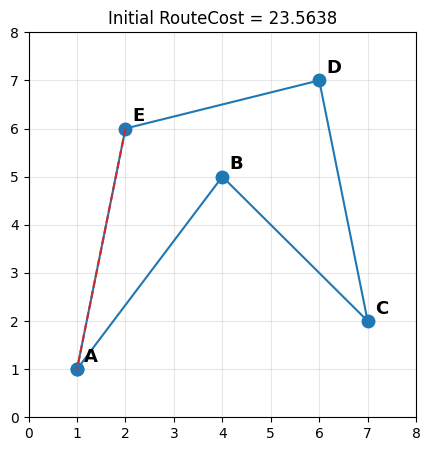

In [6]:
def plot_route(route, title, ax=None):
    # Gambar kota, label, garis rute, dan garis kembali ke kota awal
    show = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    path = route + [route[0]]
    xs = [cities[c][0] for c in path]
    ys = [cities[c][1] for c in path]
    ax.plot(xs, ys, "-o", color="tab:blue", markersize=9, zorder=2)
    ax.plot(xs[-2:], ys[-2:], "--", color="tab:red", zorder=3)  # edge kembali ke awal
    for name, (x, y) in cities.items():
        ax.text(x + 0.15, y + 0.15, name, fontsize=13, fontweight="bold")
    ax.set_title(f"{title}\
Cost = {calculate_route_cost(route):.4f}")
    ax.set_xlim(0, 8); ax.set_ylim(0, 8)
    ax.grid(True, alpha=0.3)
    if show:
        plt.show()

initial_route = ["A", "B", "C", "D", "E"]
print("Initial Route:", route_to_string(initial_route))
print(f"Initial Cost : {calculate_route_cost(initial_route):.4f}")
plot_route(initial_route, "Initial Route")

## 9. Generate Neighbors
**Neighbor** = state lain yang bisa dicapai dengan **satu perubahan kecil**. Di sini perubahan kecil itu adalah **swap**: menukar posisi dua kota di dalam route.

Contoh: tukar posisi 1 dan 2 pada `[A, B, C, D, E]` → `[A, C, B, D, E]`. Dengan 5 posisi, jumlah pasangan yang bisa ditukar adalah C(5,2) = **10 neighbor**. Kode memakai dua loop bersarang (`i` dan `j > i`) supaya setiap pasangan hanya dihitung sekali.

In [7]:
def generate_neighbors(route):
    neighbors = []
    for i in range(len(route)):
        for j in range(i + 1, len(route)):
            neighbor = route.copy()
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            neighbors.append(neighbor)
    return neighbors

neighbors = generate_neighbors(initial_route)
print("Jumlah neighbor:", len(neighbors))
for n in neighbors[:5]:
    print(route_to_string(n))

Jumlah neighbor: 10
B → A → C → D → E → B
C → B → A → D → E → C
D → B → C → A → E → D
E → B → C → D → A → E
A → C → B → D → E → A


## 10. Evaluasi Neighbors
Sekarang kita nilai semua 10 neighbor dan urutkan dari cost terkecil. **Baris paling atas** adalah neighbor terbaik, dan itulah yang akan dipilih Hill Climbing.

Bandingkan dengan *Current cost* yang dicetak: kalau cost neighbor terbaik lebih kecil, berarti ada peluang untuk berpindah. Dua neighbor bisa punya cost sama karena swap yang berbeda kadang menghasilkan tour yang sama (hanya beda titik awal atau arah).

In [8]:
rows = []
for k, n in enumerate(neighbors, start=1):
    rows.append({"Neighbor": k, "Route": route_to_string(n), "Cost": round(calculate_route_cost(n), 4)})

df_neighbors = pd.DataFrame(rows).sort_values("Cost").reset_index(drop=True)
print(f"Current cost: {calculate_route_cost(initial_route):.4f}")
df_neighbors

Current cost: 23.5638


,Neighbor,Route,Cost
0,3,D → B → C → A → E → D,22.3760
1,5,A → C → B → D → E → A,22.3760
2,1,B → A → C → D → E → B,22.5410
3,9,A → B → E → D → C → A,22.5410
4,8,A → B → D → C → E → A,24.4296
5,7,A → E → C → D → B → A,24.4296
6,6,A → D → C → B → E → A,24.4870
7,4,E → B → C → D → A → E,24.4870
8,2,C → B → A → D → E → C,27.5791
9,10,A → B → C → E → D → A,27.5791


## 11. Implementasi Hill Climbing
Pola kuncinya:

1. hitung cost semua neighbor, ambil yang **terkecil**;
2. jika lebih kecil dari cost sekarang → **Move** (current diganti);
3. jika tidak → **Stop** (tidak ada improvement lagi).

Setiap iterasi disimpan ke `history` supaya di cell berikutnya kita bisa **melihat** apa yang terjadi, bukan hanya hasil akhirnya.

In [9]:
def hill_climbing(initial_route):
    current = initial_route.copy()
    current_cost = calculate_route_cost(current)
    history = []
    iteration = 0

    while True:
        # 1) Buat semua neighbor dari current, lalu 2) hitung cost masing-masing
        neighbors = generate_neighbors(current)
        costs = [calculate_route_cost(n) for n in neighbors]
        best_idx = costs.index(min(costs))       # neighbor dengan cost terkecil
        best_neighbor = neighbors[best_idx]
        best_cost = costs[best_idx]

        # 3) Pindah HANYA jika neighbor terbaik lebih baik (cost lebih kecil)
        if best_cost < current_cost:
            decision = "Move"
        else:
            decision = "Stop"

        history.append({
            "Iteration": iteration,
            "Current Route": current.copy(),
            "Current Cost": current_cost,
            "Best Neighbor": best_neighbor,
            "Best Neighbor Cost": best_cost,
            "Decision": decision,
        })

        if decision == "Stop":
            break
        # Pindah: neighbor terbaik menjadi current untuk iterasi berikutnya
        current, current_cost = best_neighbor, best_cost
        iteration += 1

    return current, current_cost, history

## 12. Trace Setiap Iterasi

- **Current Route / Cost**: posisi kita saat ini.
- **Best Neighbor / Cost**: neighbor terbaik yang ditemukan dari posisi tersebut.
- **Decision**: `Move` jika neighbor lebih baik, `Stop` jika tidak.

Cost pada baris `Move` selalu lebih kecil dari baris sebelumnya. Baris terakhir adalah `Stop`: neighbor terbaik pun tidak lebih baik dari current.

In [10]:
final_route, final_cost, history = hill_climbing(initial_route)

def history_to_df(history):
    return pd.DataFrame([{
        "Iteration": h["Iteration"],
        "Current Route": route_to_string(h["Current Route"]),
        "Current Cost": round(h["Current Cost"], 4),
        "Best Neighbor": route_to_string(h["Best Neighbor"]),
        "Best Neighbor Cost": round(h["Best Neighbor Cost"], 4),
        "Decision": h["Decision"],
    } for h in history])

df_history = history_to_df(history)
print("Final Route:", route_to_string(final_route))
print(f"Final Cost : {final_cost:.4f}")
df_history

Final Route: B → D → C → A → E → B
Final Cost : 21.3453


,Iteration,Current Route,Current Cost,Best Neighbor,Best Neighbor Cost,Decision
0,0,A → B → C → D → E → A,23.5638,D → B → C → A → E → D,22.3760,Move
1,1,D → B → C → A → E → D,22.3760,B → D → C → A → E → B,21.3453,Move
2,2,B → D → C → A → E → B,21.3453,B → D → E → A → C → B,22.3760,Stop


## 13. Visualisasi Route
Tabel menunjukkan angka; gambar menunjukkan **bentuk rute**. Tiga plot di bawah memperlihatkan route awal, route di tengah proses, dan route akhir. Perhatikan garis yang saling **menyilang** pada route awal: biasanya route yang lebih pendek lebih sedikit menyilang.

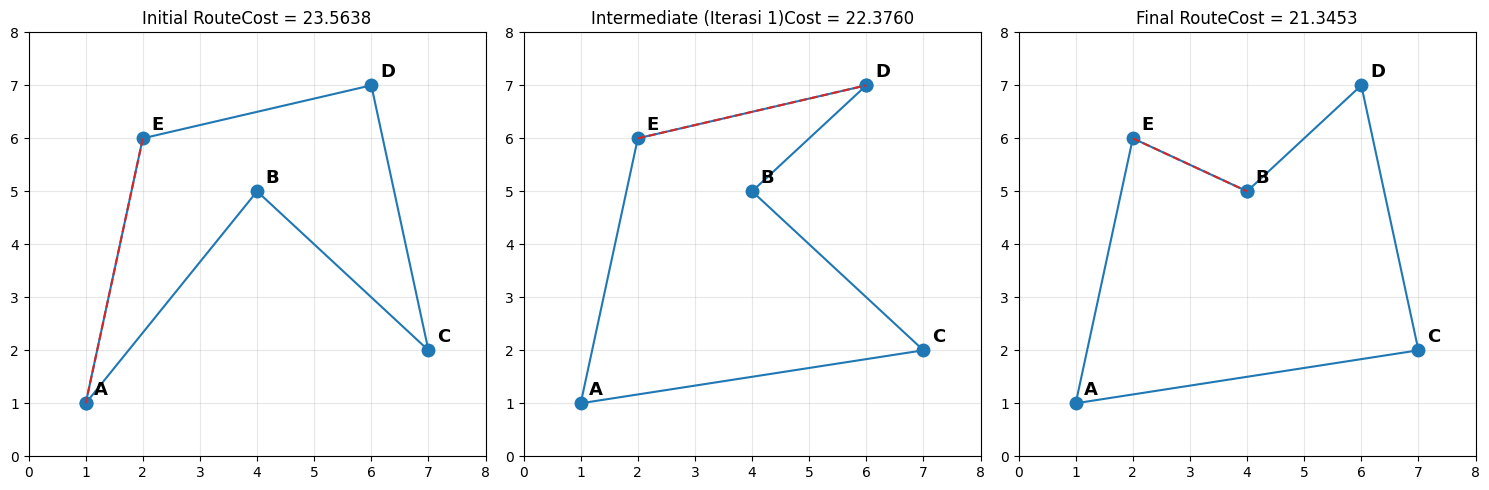

In [11]:
# Intermediate = route pada iterasi tengah (jika ada), selain initial dan final
mid_idx = len(history) // 2
intermediate_route = history[mid_idx]["Current Route"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_route(initial_route, "Initial Route", axes[0])
plot_route(intermediate_route, f"Intermediate (Iterasi {history[mid_idx]['Iteration']})", axes[1])
plot_route(final_route, "Final Route", axes[2])
plt.tight_layout()
plt.show()

## 14. Eksperimen dengan Initial State Berbeda
Hill Climbing bersifat **deterministik**: dari initial state yang sama, hasilnya selalu sama. Tetapi kalau initial state diganti, jalurnya bisa berbeda dan hasil akhirnya juga bisa berbeda. Kita coba 3 titik awal dan bandingkan tabelnya. Kolom `Iterations` menghitung jumlah langkah **Move**.

In [19]:
initial_routes = {
    "Experiment 1": ["A", "B", "C", "D", "E"],
    "Experiment 2": ["A", "C", "B", "E", "D"],
    "Experiment 3": ["D", "A", "E", "B", "C"],
}

experiment_results = {}
rows = []
for name, init in initial_routes.items():
    f_route, f_cost, hist = hill_climbing(init)
    experiment_results[name] = (f_route, f_cost, hist)
    rows.append({
        "Experiment": name,
        "Initial Route": route_to_string(init),
        "Initial Cost": round(calculate_route_cost(init), 4),
        "Final Route": route_to_string(f_route),
        "Final Cost": round(f_cost, 4),
        "Iterations": len(hist) - 1,   # jumlah langkah Move
    })

df_experiments = pd.DataFrame(rows)
df_experiments

,Experiment,Initial Route,Initial Cost,Final Route,Final Cost,Iterations
0,Experiment 1,A → B → C → D → E → A,23.5638,B → D → C → A → E → B,21.3453,2
1,Experiment 2,A → C → B → E → D → A,24.4948,B → E → A → C → D → B,21.3453,2
2,Experiment 3,D → A → E → B → C → D,24.4870,C → A → E → B → D → C,21.3453,1


## 15. Analisis Local Optimum
**Local optimum** = state yang lebih baik dari semua neighbor-nya, tetapi **belum tentu** yang terbaik dari seluruh kemungkinan. Bayangkan mendaki bukit dalam kabut: kita berhenti di puncak kecil karena semua langkah sekitar menurun, padahal ada gunung lebih tinggi di tempat lain.


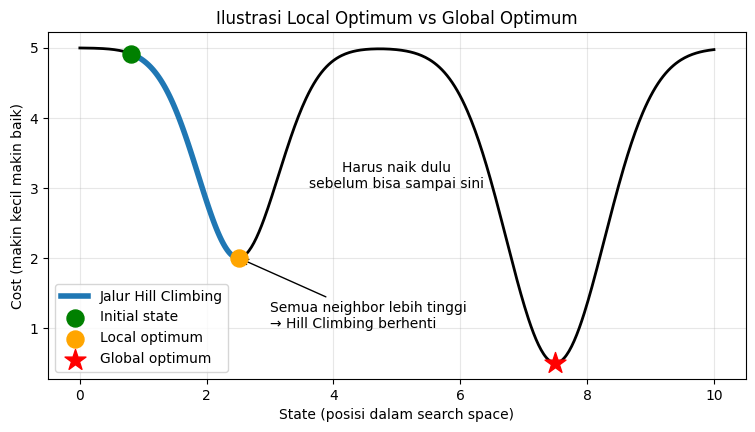

In [15]:
# ILUSTRASI KONSEPTUAL
x = np.linspace(0, 10, 500)
cost_curve = 5 - 3 * np.exp(-(x - 2.5) ** 2 / 0.8) - 4.5 * np.exp(-(x - 7.5) ** 2 / 1.2)

i_local = np.argmin(np.where(x < 5, cost_curve, np.inf))    # lembah kiri
i_global = np.argmin(np.where(x > 5, cost_curve, np.inf))   # lembah kanan
i_start = np.argmin(abs(x - 0.8))

plt.figure(figsize=(9, 4.5))
plt.plot(x, cost_curve, color="black", lw=2)
# jalur Hill Climbing: turun dari start sampai lembah kiri
plt.plot(x[i_start:i_local + 1], cost_curve[i_start:i_local + 1], color="tab:blue", lw=4,
         label="Jalur Hill Climbing")
plt.scatter(x[i_start], cost_curve[i_start], s=150, color="green", zorder=5, label="Initial state")
plt.scatter(x[i_local], cost_curve[i_local], s=150, color="orange", zorder=5, label="Local optimum")
plt.scatter(x[i_global], cost_curve[i_global], s=250, color="red", marker="*", zorder=5, label="Global optimum")
plt.annotate("Semua neighbor lebih tinggi\n→ Hill Climbing berhenti", xy=(x[i_local], cost_curve[i_local]),
             xytext=(3.0, 1.0), arrowprops=dict(arrowstyle="->"))
plt.annotate("Harus naik dulu\nsebelum bisa sampai sini", xy=(5, cost_curve[np.argmin(abs(x - 5))]),
             xytext=(5.0, 3.0), ha="center")
plt.xlabel("State (posisi dalam search space)")
plt.ylabel("Cost (makin kecil makin baik)")
plt.title("Ilustrasi Local Optimum vs Global Optimum")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 16. Kesimpulan
- TSP dapat dimodelkan sebagai masalah **Local Search**.
- **Route** adalah state.
- **Swap** dua posisi menghasilkan neighbor.
- **Total distance** adalah cost function.
- Hill Climbing memilih neighbor dengan cost lebih rendah.
- Algoritma **berhenti** ketika tidak ada improvement.
- **Initial state** dapat memengaruhi hasil.
- Hill Climbing **dapat terjebak** pada local optimum.